# MaStR vs. SMARD: installed capacity

The Bundesnetzagentur publishes its own official year-end installed-
capacity figures via SMARD, independently of the unit-level MaStR
register. Comparing the two is a useful sanity check on the MaStR-derived
numbers used throughout the rest of this book -- unlike a one-off,
hand-copied comparison against a single year's press release, this reads
both sides live from `energy-data-hub` so it stays current automatically.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from insights.paths import hub_file

panel = pd.read_parquet(hub_file("capacity", "capacity_by_region_year.parquet"))

TECHNOLOGIES = ["solar", "wind_onshore", "wind_offshore"]
TECHNOLOGY_LABELS = {"solar": "Solar", "wind_onshore": "Wind (onshore)", "wind_offshore": "Wind (offshore)"}
TECHNOLOGY_COLORS = {"solar": "#E8A33D", "wind_onshore": "#1B7A9C", "wind_offshore": "#8B4A1E"}

## MaStR side: national annual totals

Summed across all regions per year; wind is split into onshore/offshore
using the same `DEZZ` offshore pseudo-region convention used elsewhere in
this book. Includes the current (still-incomplete) year -- MaStR's
"year-end" snapshot for it is really just "as of today".

In [2]:
is_offshore = panel["region_code"].str.startswith("DEZZ")
mastr_national = pd.DataFrame({
    "solar": panel[panel["technology"] == "solar"].groupby("year")["capacity_mw"].sum(),
    "wind_onshore": panel[(panel["technology"] == "wind") & ~is_offshore].groupby("year")["capacity_mw"].sum(),
    "wind_offshore": panel[(panel["technology"] == "wind") & is_offshore].groupby("year")["capacity_mw"].sum(),
})
mastr_national.tail()

,solar,wind_onshore,wind_offshore
year,,,
2022,61207.246707,57578.912577,8216.018
2023,74749.042702,60561.224467,8473.193
2024,89853.589735,63118.485147,9215.093
2025,104702.674288,67717.724447,9733.493
2026,111491.319665,69757.710017,10855.643


## SMARD side: official year-end capacity

SMARD's own capacity series are published hourly but only actually change
value a handful of times a year -- effectively a year-end (Dec 31)
snapshot repeated forward until the next update, the same cadence as
MaStR's annual panel above.

In [3]:
smard_national = pd.DataFrame({
    tech: pd.read_parquet(hub_file("smard", f"capacity_{tech}.parquet")).resample("YE").last().iloc[:, 0]
    for tech in TECHNOLOGIES
})
smard_national.index = smard_national.index.year
smard_national.tail()

,solar,wind_onshore,wind_offshore
timestamp,,,
2022,63066.0,57590.0,8129.0
2023,76601.0,59841.0,8456.0
2024,86408.0,63192.0,9215.0
2025,103260.0,67693.0,9226.0
2026,103260.0,67693.0,9226.0


## Current installed capacity

Where things stand *right now*: MaStR's live snapshot next to SMARD's most
recently published figure. These two are **not** a like-for-like
comparison -- SMARD only updates a handful of times a year, so its number
can lag today's real installed capacity by close to a year. This section
answers "how much is installed today", not "do the two sources agree"
(that's the next section, restricted to a year both sides have actually
reported).

In [4]:
today = pd.Timestamp.today()
smard_last_change = {}
smard_last_value = {}
for tech in TECHNOLOGIES:
    raw = pd.read_parquet(hub_file("smard", f"capacity_{tech}.parquet")).iloc[:, 0]
    changes = raw[raw.diff().ne(0)]
    smard_last_change[tech] = changes.index[-1].date()
    smard_last_value[tech] = changes.iloc[-1]

current = pd.DataFrame({
    "mastr_mw_today": mastr_national.iloc[-1],
    "smard_mw_last_published": pd.Series(smard_last_value),
    "smard_last_updated": pd.Series(smard_last_change),
})
print(f"MaStR as of {today.date()} vs. SMARD's own last real update per technology:")
print(current)

MaStR as of 2026-09-24 vs. SMARD's own last real update per technology:
               mastr_mw_today  smard_mw_last_published smard_last_updated
solar           111491.319665                 103260.0         2025-12-31
wind_onshore     69757.710017                  67693.0         2025-12-31
wind_offshore    10855.643000                   9226.0         2025-12-31


## Evolution over time

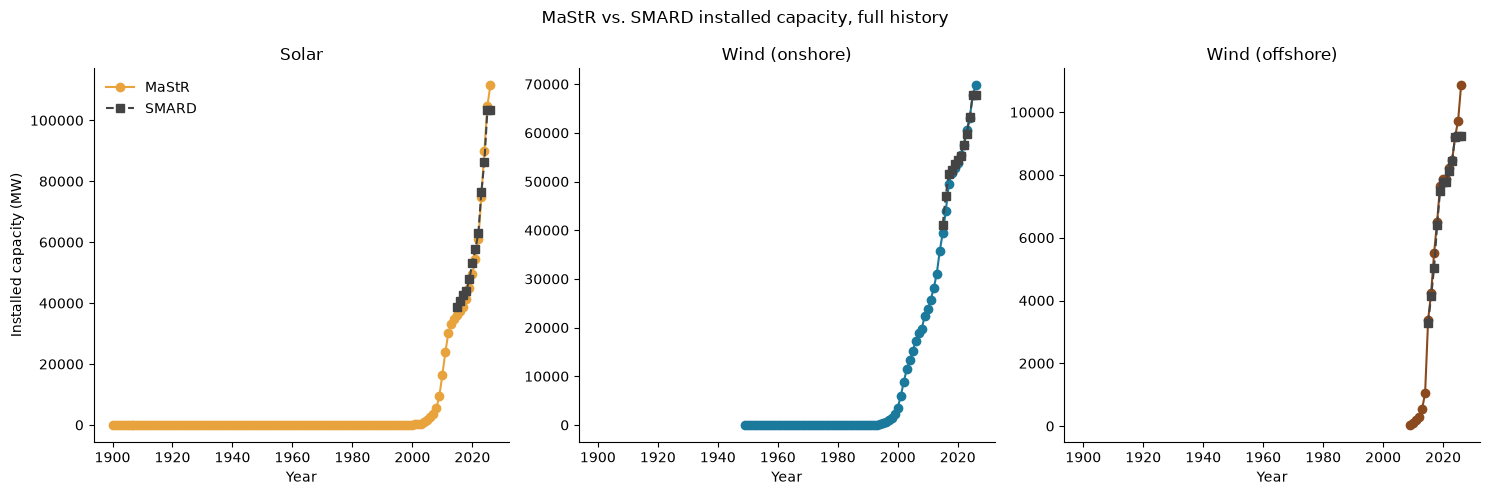

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)
for ax, tech in zip(axes, TECHNOLOGIES):
    ax.plot(mastr_national.index, mastr_national[tech], marker="o", label="MaStR", color=TECHNOLOGY_COLORS[tech])
    ax.plot(smard_national.index, smard_national[tech], marker="s", linestyle="--", label="SMARD", color="#444444")
    ax.set_title(TECHNOLOGY_LABELS[tech])
    ax.set_xlabel("Year")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Installed capacity (MW)")
axes[0].legend(loc="upper left", frameon=False)
fig.suptitle("MaStR vs. SMARD installed capacity, full history")
fig.tight_layout()
plt.show()

MaStR's line runs one point further right than SMARD's -- that's the
current, still-incomplete year discussed above, not a data problem.

## Do the two sources agree? (latest fully completed year)

The current year is excluded here: MaStR's snapshot for it means
"capacity as of today", while SMARD's own figure for it is just last
year's number carried forward until they publish a real update --
including it would make MaStR look artificially ahead by however many
months have elapsed this year, not because it actually is.

In [6]:
current_year = today.year
common_years = mastr_national.index.intersection(smard_national.index)
completed_years = common_years[common_years < current_year]

latest_completed_year = completed_years.max()
comparison = pd.DataFrame({
    "mastr_mw": mastr_national.loc[latest_completed_year],
    "smard_mw": smard_national.loc[latest_completed_year],
})
comparison["diff_mw"] = comparison["mastr_mw"] - comparison["smard_mw"]
comparison["diff_pct"] = 100 * comparison["diff_mw"] / comparison["smard_mw"]
print(f"Year: {latest_completed_year}")
print(comparison.round(1))

Year: 2025
               mastr_mw  smard_mw  diff_mw  diff_pct
solar          104702.7  103260.0   1442.7       1.4
wind_onshore    67717.7   67693.0     24.7       0.0
wind_offshore    9733.5    9226.0    507.5       5.5


Onshore and offshore wind typically match SMARD closely (within a few
percent). Solar's match varies more year to year -- a known
characteristic of MaStR rather than a data-pipeline bug: it's a
self-reported registry, and small rooftop PV systems in particular are
often registered with a lag of months, so the most recent year is always
somewhat under- or overcounted until later backfilling catches up (see
the [open-mastr data quality paper](https://doi.org/10.1145/3717413.3717421)
referenced in its docs).

## Full history, side by side

In [7]:
full_comparison = pd.concat(
    {tech: pd.DataFrame({"mastr_mw": mastr_national.loc[completed_years, tech], "smard_mw": smard_national.loc[completed_years, tech]}) for tech in TECHNOLOGIES},
    axis=1,
)
full_comparison.round(0)

solar           wind_onshore          wind_offshore         
      mastr_mw  smard_mw     mastr_mw smard_mw      mastr_mw smard_mw
2015   35989.0   38686.0      39496.0  41168.0        3382.0   3283.0
2016   37313.0   40834.0      43897.0  47042.0        4237.0   4131.0
2017   38799.0   42804.0      49388.0  51633.0        5523.0   5051.0
2018   41418.0   44036.0      51833.0  52394.0        6513.0   6393.0
2019   44989.0   47754.0      52684.0  53553.0        7655.0   7504.0
2020   49546.0   53302.0      53869.0  54499.0        7874.0   7774.0
2021   54559.0   57744.0      55506.0  55289.0        7874.0   7787.0
2022   61207.0   63066.0      57579.0  57590.0        8216.0   8129.0
2023   74749.0   76601.0      60561.0  59841.0        8473.0   8456.0
2024   89854.0   86408.0      63118.0  63192.0        9215.0   9215.0
2025  104703.0  103260.0      67718.0  67693.0        9733.0   9226.0